# 07 — `wavelet`: time-frequency

`pha, amp, freqs = dsp.wavelet(x, fs)` returns per-frequency
phase/amplitude — a continuous wavelet transform. The outputs are
torch tensors; convert to numpy with `.cpu().numpy()` before
plotting.

amp: (1, 1, 256, 1024) freqs: (256,)


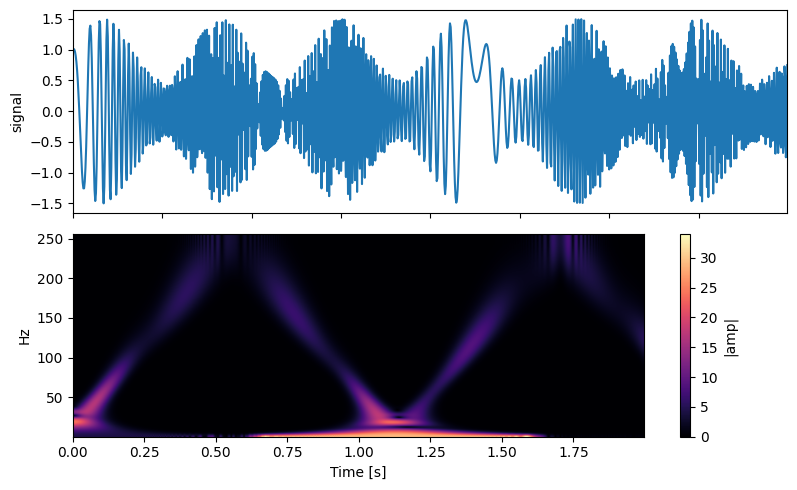

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import torch
import scitex_dsp as dsp
%matplotlib inline

xx, tt, fs = dsp.demo_sig(sig_type="chirp", batch_size=1, n_chs=1,
                          t_sec=2, fs=512)
pha, amp, freqs = dsp.wavelet(xx, fs=fs, device="cpu")

def to_np(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

amp_np = to_np(amp); freqs_np = to_np(freqs).ravel()
print("amp:", amp_np.shape, "freqs:", freqs_np.shape)

fig, ax = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
ax[0].plot(tt, xx[0, 0]); ax[0].set_ylabel("signal")
im = ax[1].imshow(amp_np[0, 0], aspect="auto", origin="lower",
                  extent=[tt[0], tt[-1], freqs_np[0], freqs_np[-1]],
                  cmap="magma")
ax[1].set_ylabel("Hz"); ax[1].set_xlabel("Time [s]")
fig.colorbar(im, ax=ax[1], label="|amp|"); fig.tight_layout()
plt.show()
